# NBA Home Win Probability

Predict home-team win probability from pre-game information only.

**Data**: single supplied CSV of 2025-26 NBA games  
**Split**: Train (before March 2026) / Validation (March) / Hold-out (April)  
**Models**: Log5, Logistic Regression, Random Forest, XGBoost  
**Primary metrics**: Brier score, log-loss

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    brier_score_loss, log_loss, accuracy_score, roc_auc_score
)
from sklearn.calibration import calibration_curve
import xgboost as xgb
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load data

In [2]:
CSV_PATH = Path("nba_games.csv")
df_raw = pd.read_csv(CSV_PATH)
df_raw["game_date"] = pd.to_datetime(df_raw["game_date"])
df_raw = df_raw.sort_values(["game_date", "game_id"]).reset_index(drop=True)

print(f"Games: {len(df_raw):,}")
print(f"Date range: {df_raw['game_date'].min().date()} → {df_raw['game_date'].max().date()}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head(3)

Games: 1,230
Date range: 2025-10-21 → 2026-04-12
Columns: ['game_id', 'game_date', 'away', 'away_wins', 'away_losses', 'away_points', 'away_turnovers', 'away_fouls', 'away_rebounds', 'home', 'home_wins', 'home_losses', 'home_points', 'home_turnovers', 'home_fouls', 'home_rebounds']


,game_id,game_date,away,away_wins,away_losses,away_points,away_turnovers,away_fouls,away_rebounds,home,home_wins,home_losses,home_points,home_turnovers,home_fouls,home_rebounds
0,22500001,2025-10-21,HOU,0,0,124,25,26,73,OKC,0,0,125,12,27,49
1,22500002,2025-10-21,GSW,0,0,119,19,27,41,LAL,0,0,109,20,21,49
2,22500003,2025-10-22,CLE,0,0,111,15,26,50,NYK,0,0,119,14,23,58


## 2. Construct pre-game features

All features use only information available before tip-off.  
Running team statistics are updated *after* the features for each game have been extracted, eliminating leakage.

Opponent box-score stats supply the complementary quantities:
- points allowed = opponent points
- rebounds allowed = opponent rebounds
- takeaways = opponent turnovers
- fouls drawn = opponent fouls

In [3]:
from collections import defaultdict

def safe_pct(wins, games):
    return wins / games if games > 0 else np.nan

def safe_mean(total, games):
    return total / games if games > 0 else np.nan

# Running state per team
state = defaultdict(lambda: {
    # overall
    "games": 0, "wins": 0,
    "pts": 0.0, "pts_allowed": 0.0,
    "reb": 0.0, "reb_allowed": 0.0,
    "tov": 0.0, "takeaways": 0.0,
    "fouls": 0.0, "fouls_drawn": 0.0,
    # home
    "games_home": 0, "wins_home": 0,
    "pts_home": 0.0, "pts_allowed_home": 0.0,
    "reb_home": 0.0, "reb_allowed_home": 0.0,
    "tov_home": 0.0, "takeaways_home": 0.0,
    "fouls_home": 0.0, "fouls_drawn_home": 0.0,
    # road
    "games_road": 0, "wins_road": 0,
    "pts_road": 0.0, "pts_allowed_road": 0.0,
    "reb_road": 0.0, "reb_allowed_road": 0.0,
    "tov_road": 0.0, "takeaways_road": 0.0,
    "fouls_road": 0.0, "fouls_drawn_road": 0.0,
    # calendar
    "last_date": None,
})

rows = []

for _, g in df_raw.iterrows():
    home = g["home"]
    away = g["away"]
    date = g["game_date"]

    hs = state[home]
    as_ = state[away]

    # ----- extract pre-game features (using state BEFORE this game) -----
    feat = {
        "game_id": g["game_id"],
        "game_date": date,
        "home": home,
        "away": away,
        # target
        "home_win": int(g["home_points"] > g["away_points"]),
        # strength
        "home_win_pct_overall": safe_pct(hs["wins"], hs["games"]),
        "away_win_pct_overall": safe_pct(as_["wins"], as_["games"]),
        "home_win_pct_at_home": safe_pct(hs["wins_home"], hs["games_home"]),
        "away_win_pct_on_road": safe_pct(as_["wins_road"], as_["games_road"]),
        # points
        "home_points_overall": safe_mean(hs["pts"], hs["games"]),
        "away_points_overall": safe_mean(as_["pts"], as_["games"]),
        "home_points_at_home": safe_mean(hs["pts_home"], hs["games_home"]),
        "away_points_on_road": safe_mean(as_["pts_road"], as_["games_road"]),
        "home_points_allowed_overall": safe_mean(hs["pts_allowed"], hs["games"]),
        "away_points_allowed_overall": safe_mean(as_["pts_allowed"], as_["games"]),
        "home_points_allowed_at_home": safe_mean(hs["pts_allowed_home"], hs["games_home"]),
        "away_points_allowed_on_road": safe_mean(as_["pts_allowed_road"], as_["games_road"]),
        # rebounds + nets
        "home_rebounds_overall": safe_mean(hs["reb"], hs["games"]),
        "away_rebounds_overall": safe_mean(as_["reb"], as_["games"]),
        "home_rebounds_allowed_overall": safe_mean(hs["reb_allowed"], hs["games"]),
        "away_rebounds_allowed_overall": safe_mean(as_["reb_allowed"], as_["games"]),
        "home_rebounds_net_overall": safe_mean(hs["reb"] - hs["reb_allowed"], hs["games"]),
        "away_rebounds_net_overall": safe_mean(as_["reb"] - as_["reb_allowed"], as_["games"]),
        "home_rebounds_net_at_home": safe_mean(hs["reb_home"] - hs["reb_allowed_home"], hs["games_home"]),
        "away_rebounds_net_on_road": safe_mean(as_["reb_road"] - as_["reb_allowed_road"], as_["games_road"]),
        # turnovers + nets
        "home_turnovers_overall": safe_mean(hs["tov"], hs["games"]),
        "away_turnovers_overall": safe_mean(as_["tov"], as_["games"]),
        "home_takeaways_overall": safe_mean(hs["takeaways"], hs["games"]),
        "away_takeaways_overall": safe_mean(as_["takeaways"], as_["games"]),
        "home_turnovers_net_overall": safe_mean(hs["tov"] - hs["takeaways"], hs["games"]),
        "away_turnovers_net_overall": safe_mean(as_["tov"] - as_["takeaways"], as_["games"]),
        "home_turnovers_net_at_home": safe_mean(hs["tov_home"] - hs["takeaways_home"], hs["games_home"]),
        "away_turnovers_net_on_road": safe_mean(as_["tov_road"] - as_["takeaways_road"], as_["games_road"]),
        # fouls + nets
        "home_fouls_overall": safe_mean(hs["fouls"], hs["games"]),
        "away_fouls_overall": safe_mean(as_["fouls"], as_["games"]),
        "home_fouls_drawn_overall": safe_mean(hs["fouls_drawn"], hs["games"]),
        "away_fouls_drawn_overall": safe_mean(as_["fouls_drawn"], as_["games"]),
        "home_fouls_net_overall": safe_mean(hs["fouls"] - hs["fouls_drawn"], hs["games"]),
        "away_fouls_net_overall": safe_mean(as_["fouls"] - as_["fouls_drawn"], as_["games"]),
        "home_fouls_net_at_home": safe_mean(hs["fouls_home"] - hs["fouls_drawn_home"], hs["games_home"]),
        "away_fouls_net_on_road": safe_mean(as_["fouls_road"] - as_["fouls_drawn_road"], as_["games_road"]),
        # context
        "home_games_played": hs["games"],
        "away_games_played": as_["games"],
    }

    # rest days
    if hs["last_date"] is not None:
        feat["home_rest_days"] = (date - hs["last_date"]).days - 1
    else:
        feat["home_rest_days"] = np.nan
    if as_["last_date"] is not None:
        feat["away_rest_days"] = (date - as_["last_date"]).days - 1
    else:
        feat["away_rest_days"] = np.nan

    rows.append(feat)

    # ----- now update state with THIS game (after features extracted) -----
    # home team (played at home)
    hs["games"] += 1
    hs["wins"] += int(g["home_points"] > g["away_points"])
    hs["pts"] += g["home_points"]
    hs["pts_allowed"] += g["away_points"]
    hs["reb"] += g["home_rebounds"]
    hs["reb_allowed"] += g["away_rebounds"]
    hs["tov"] += g["home_turnovers"]
    hs["takeaways"] += g["away_turnovers"]
    hs["fouls"] += g["home_fouls"]
    hs["fouls_drawn"] += g["away_fouls"]

    hs["games_home"] += 1
    hs["wins_home"] += int(g["home_points"] > g["away_points"])
    hs["pts_home"] += g["home_points"]
    hs["pts_allowed_home"] += g["away_points"]
    hs["reb_home"] += g["home_rebounds"]
    hs["reb_allowed_home"] += g["away_rebounds"]
    hs["tov_home"] += g["home_turnovers"]
    hs["takeaways_home"] += g["away_turnovers"]
    hs["fouls_home"] += g["home_fouls"]
    hs["fouls_drawn_home"] += g["away_fouls"]

    hs["last_date"] = date

    # away team (played on road)
    as_["games"] += 1
    as_["wins"] += int(g["away_points"] > g["home_points"])
    as_["pts"] += g["away_points"]
    as_["pts_allowed"] += g["home_points"]
    as_["reb"] += g["away_rebounds"]
    as_["reb_allowed"] += g["home_rebounds"]
    as_["tov"] += g["away_turnovers"]
    as_["takeaways"] += g["home_turnovers"]
    as_["fouls"] += g["away_fouls"]
    as_["fouls_drawn"] += g["home_fouls"]

    as_["games_road"] += 1
    as_["wins_road"] += int(g["away_points"] > g["home_points"])
    as_["pts_road"] += g["away_points"]
    as_["pts_allowed_road"] += g["home_points"]
    as_["reb_road"] += g["away_rebounds"]
    as_["reb_allowed_road"] += g["home_rebounds"]
    as_["tov_road"] += g["away_turnovers"]
    as_["takeaways_road"] += g["home_turnovers"]
    as_["fouls_road"] += g["away_fouls"]
    as_["fouls_drawn_road"] += g["home_fouls"]

    as_["last_date"] = date

df = pd.DataFrame(rows)

# derived differentials / sums (still pre-game)
df["points_overall_diff"] = df["home_points_overall"] - df["away_points_overall"]
df["points_allowed_overall_diff"] = df["home_points_allowed_overall"] - df["away_points_allowed_overall"]
df["rebounds_net_overall_diff"] = df["home_rebounds_net_overall"] - df["away_rebounds_net_overall"]
df["turnovers_net_overall_diff"] = df["home_turnovers_net_overall"] - df["away_turnovers_net_overall"]
df["fouls_net_overall_diff"] = df["home_fouls_net_overall"] - df["away_fouls_net_overall"]
df["rest_days_diff"] = df["home_rest_days"] - df["away_rest_days"]
df["games_played_diff"] = df["home_games_played"] - df["away_games_played"]
df["games_played_sum"] = df["home_games_played"] + df["away_games_played"]

print(f"Feature matrix shape: {df.shape}")
print(f"Home win rate: {df['home_win'].mean():.3f}")
df.head(3)

Feature matrix shape: (1230, 53)
Home win rate: 0.554


,game_id,game_date,home,away,home_win,home_win_pct_overall,away_win_pct_overall,home_win_pct_at_home,away_win_pct_on_road,home_points_overall,away_points_overall,home_points_at_home,away_points_on_road,home_points_allowed_overall,away_points_allowed_overall,home_points_allowed_at_home,away_points_allowed_on_road,home_rebounds_overall,away_rebounds_overall,home_rebounds_allowed_overall,away_rebounds_allowed_overall,home_rebounds_net_overall,away_rebounds_net_overall,home_rebounds_net_at_home,away_rebounds_net_on_road,home_turnovers_overall,away_turnovers_overall,home_takeaways_overall,away_takeaways_overall,home_turnovers_net_overall,away_turnovers_net_overall,home_turnovers_net_at_home,away_turnovers_net_on_road,home_fouls_overall,away_fouls_overall,home_fouls_drawn_overall,away_fouls_drawn_overall,home_fouls_net_overall,away_fouls_net_overall,home_fouls_net_at_home,away_fouls_net_on_road,home_games_played,away_games_played,home_rest_days,away_rest_days,points_overall_diff,points_allowed_overall_diff,rebounds_net_overall_diff,turnovers_net_overall_diff,fouls_net_overall_diff,rest_days_diff,games_played_diff,games_played_sum
0,22500001,2025-10-21,OKC,HOU,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,22500002,2025-10-21,LAL,GSW,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
2,22500003,2025-10-22,NYK,CLE,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0


## 3. Feature regimes

In [4]:
S0 = [
    "home_win_pct_overall",
    "away_win_pct_overall",
]

S1 = [
    "home_win_pct_overall",
    "away_win_pct_overall",
    "points_overall_diff",
    "points_allowed_overall_diff",
    "rest_days_diff",
    "rebounds_net_overall_diff",
    "turnovers_net_overall_diff",
    "fouls_net_overall_diff",
    "games_played_diff",
    "games_played_sum",
]

S2 = S1 + [
    "home_win_pct_at_home",
    "away_win_pct_on_road",
    "home_points_at_home",
    "away_points_on_road",
    "home_points_allowed_at_home",
    "away_points_allowed_on_road",
    "home_rebounds_net_at_home",
    "away_rebounds_net_on_road",
    "home_turnovers_net_at_home",
    "away_turnovers_net_on_road",
    "home_fouls_net_at_home",
    "away_fouls_net_on_road",
]

S3 = [
    # strength
    "home_win_pct_overall", "away_win_pct_overall",
    "home_win_pct_at_home", "away_win_pct_on_road",
    # offense
    "home_points_overall", "away_points_overall",
    "home_points_at_home", "away_points_on_road",
    # defense
    "home_points_allowed_overall", "away_points_allowed_overall",
    "home_points_allowed_at_home", "away_points_allowed_on_road",
    # rebounding nets
    "home_rebounds_net_overall", "away_rebounds_net_overall",
    "home_rebounds_net_at_home", "away_rebounds_net_on_road",
    # turnover nets
    "home_turnovers_net_overall", "away_turnovers_net_overall",
    "home_turnovers_net_at_home", "away_turnovers_net_on_road",
    # foul nets
    "home_fouls_net_overall", "away_fouls_net_overall",
    "home_fouls_net_at_home", "away_fouls_net_on_road",
    # context
    "rest_days_diff", "games_played_diff", "games_played_sum",
]

FEATURE_SETS = {"S0": S0, "S1": S1, "S2": S2, "S3": S3}

for name, feats in FEATURE_SETS.items():
    print(f"{name}: {len(feats)} features")

S0: 2 features
S1: 10 features
S2: 22 features
S3: 27 features


## 4. Chronological split

In [5]:
train = df[df["game_date"] < "2026-03-01"].copy()
val   = df[(df["game_date"] >= "2026-03-01") & (df["game_date"] < "2026-04-01")].copy()
hold  = df[df["game_date"] >= "2026-04-01"].copy()

print(f"Train:    {len(train):4d} games  ({train['game_date'].min().date()} → {train['game_date'].max().date()})")
print(f"Valid:    {len(val):4d} games  ({val['game_date'].min().date()} → {val['game_date'].max().date()})")
print(f"Hold-out: {len(hold):4d} games  ({hold['game_date'].min().date()} → {hold['game_date'].max().date()})")
print(f"\nHome-win rates  train={train['home_win'].mean():.3f}  val={val['home_win'].mean():.3f}  hold={hold['home_win'].mean():.3f}")

Train:     895 games  (2025-10-21 → 2026-02-28)
Valid:     239 games  (2026-03-01 → 2026-03-31)
Hold-out:   96 games  (2026-04-01 → 2026-04-12)

Home-win rates  train=0.537  val=0.603  hold=0.594


## 5. Models

In [6]:
def log5_proba(home_wp, away_wp):
    H = np.clip(home_wp, 1e-6, 1 - 1e-6)
    A = np.clip(away_wp, 1e-6, 1 - 1e-6)
    numer = H - H * A
    denom = H + A - 2 * H * A
    p = np.where(np.abs(denom) < 1e-9, 0.5, numer / denom)
    return np.clip(p, 1e-6, 1 - 1e-6)

class Log5Model:
    def fit(self, X, y=None):
        return self
    def predict_proba(self, X):
        p = log5_proba(X["home_win_pct_overall"].values, X["away_win_pct_overall"].values)
        return np.column_stack([1 - p, p])

def make_logistic():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)),
    ])

def make_rf():
    return RandomForestClassifier(
        n_estimators=300, max_depth=6, min_samples_leaf=20,
        max_features="sqrt", n_jobs=-1, random_state=RANDOM_STATE,
    )

def make_xgb():
    return xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        objective="binary:logistic", eval_metric="logloss",
        n_jobs=-1, random_state=RANDOM_STATE, verbosity=0,
    )

MODELS = {
    "log5": Log5Model,
    "logistic": make_logistic,
    "rf": make_rf,
    "xgboost": make_xgb,
}

# Log5 only on S0; others on all regimes
MODEL_SETS = {
    "log5": ["S0"],
    "logistic": ["S0", "S1", "S2", "S3"],
    "rf": ["S0", "S1", "S2", "S3"],
    "xgboost": ["S0", "S1", "S2", "S3"],
}

## 6. Train and evaluate

In [7]:
def get_xy(frame, features):
    X = frame[features].copy()
    y = frame["home_win"].values
    # median impute any residual early-season NaNs (still using only that split’s data)
    X = X.fillna(X.median(numeric_only=True))
    return X, y

results = {}          # hold-out metrics
val_results = {}      # validation metrics (for selecting best model per regime)
fitted = {}           # store models + hold-out predictions

for model_name, fsets in MODEL_SETS.items():
    for fset_name in fsets:
        feats = FEATURE_SETS[fset_name]
        key = f"{model_name}__{fset_name}"
        print(f">>> {key}  ({len(feats)} features)")

        X_tr, y_tr = get_xy(train, feats)
        X_va, y_va = get_xy(val, feats)
        X_ho, y_ho = get_xy(hold, feats)

        model = MODELS[model_name]()
        model.fit(X_tr, y_tr)

        proba_va = model.predict_proba(X_va)[:, 1]
        proba_ho = model.predict_proba(X_ho)[:, 1]

        def metrics(y, p):
            p = np.clip(p, 1e-6, 1-1e-6)
            return {
                "brier": brier_score_loss(y, p),
                "logloss": log_loss(y, p),
                "accuracy": accuracy_score(y, (p >= 0.5).astype(int)),
                "auc": roc_auc_score(y, p) if len(np.unique(y)) > 1 else np.nan,
            }

        val_results[key] = metrics(y_va, proba_va)
        results[key] = metrics(y_ho, proba_ho)
        fitted[key] = {
            "model": model,
            "features": feats,
            "y_ho": y_ho,
            "proba_ho": proba_ho,
        }

        m = results[key]
        print(f"    hold-out  Brier={m['brier']:.4f}  logloss={m['logloss']:.4f}  "
              f"acc={m['accuracy']:.3f}  auc={m['auc']:.3f}")

>>> log5__S0  (2 features)
    hold-out  Brier=0.1697  logloss=0.5175  acc=0.750  auc=0.849
>>> logistic__S0  (2 features)
    hold-out  Brier=0.1890  logloss=0.5668  acc=0.823  auc=0.857
>>> logistic__S1  (10 features)
    hold-out  Brier=0.1942  logloss=0.5737  acc=0.708  auc=0.850
>>> logistic__S2  (22 features)
    hold-out  Brier=0.2003  logloss=0.5874  acc=0.740  auc=0.830
>>> logistic__S3  (27 features)
    hold-out  Brier=0.2020  logloss=0.5912  acc=0.708  auc=0.825
>>> rf__S0  (2 features)
    hold-out  Brier=0.1797  logloss=0.5431  acc=0.771  auc=0.842
>>> rf__S1  (10 features)
    hold-out  Brier=0.1661  logloss=0.5126  acc=0.792  auc=0.862
>>> rf__S2  (22 features)
    hold-out  Brier=0.1701  logloss=0.5226  acc=0.781  auc=0.855
>>> rf__S3  (27 features)
    hold-out  Brier=0.1718  logloss=0.5262  acc=0.802  auc=0.862
>>> xgboost__S0  (2 features)
    hold-out  Brier=0.2109  logloss=0.6062  acc=0.646  auc=0.717
>>> xgboost__S1  (10 features)
    hold-out  Brier=0.1871  logl

## 7. Hold-out comparison grids

In [8]:
rows = []
for key, m in results.items():
    model, fset = key.split("__")
    rows.append({"model": model, "feature_set": fset, **m})

res_df = pd.DataFrame(rows)

for metric in ["brier", "logloss", "accuracy"]:
    pivot = res_df.pivot(index="model", columns="feature_set", values=metric)
    cols = [c for c in ["S0", "S1", "S2", "S3"] if c in pivot.columns]
    pivot = pivot[cols]
    print(f"\n=== {metric.upper()} (hold-out) ===")
    print(pivot.round(4).to_string())


=== BRIER (hold-out) ===
feature_set      S0      S1      S2      S3
model                                      
log5         0.1697     NaN     NaN     NaN
logistic     0.1890  0.1942  0.2003  0.2020
rf           0.1797  0.1661  0.1701  0.1718
xgboost      0.2109  0.1871  0.1887  0.1796

=== LOGLOSS (hold-out) ===
feature_set      S0      S1      S2      S3
model                                      
log5         0.5175     NaN     NaN     NaN
logistic     0.5668  0.5737  0.5874  0.5912
rf           0.5431  0.5126  0.5226  0.5262
xgboost      0.6062  0.5628  0.5677  0.5363

=== ACCURACY (hold-out) ===
feature_set      S0      S1      S2      S3
model                                      
log5         0.7500     NaN     NaN     NaN
logistic     0.8229  0.7083  0.7396  0.7083
rf           0.7708  0.7917  0.7812  0.8021
xgboost      0.6458  0.7396  0.7292  0.7083


## 8. Additional summary tables

Model × metric for each feature set, feature set × metric for each model, and the four locked finalists.

In [9]:
# ----- Model × metric for each feature set -----
print("=" * 60)
print("MODEL × METRIC  (for each feature set)")
print("=" * 60)
for fset in ["S0", "S1", "S2", "S3"]:
    sub = res_df[res_df["feature_set"] == fset][["model", "brier", "logloss", "accuracy"]]
    if sub.empty:
        continue
    print(f"\n--- {fset} ---")
    print(sub.set_index("model").round(4).to_string())

# ----- Feature set × metric for each model -----
print("\n" + "=" * 60)
print("FEATURE SET × METRIC  (for each model)")
print("=" * 60)
for model in ["log5", "logistic", "rf", "xgboost"]:
    sub = res_df[res_df["model"] == model][["feature_set", "brier", "logloss", "accuracy"]]
    if sub.empty:
        continue
    # order S0-S3
    order = {"S0": 0, "S1": 1, "S2": 2, "S3": 3}
    sub = sub.copy()
    sub["_ord"] = sub["feature_set"].map(order)
    sub = sub.sort_values("_ord").drop(columns="_ord")
    print(f"\n--- {model} ---")
    print(sub.set_index("feature_set").round(4).to_string())

# ----- Locked finalists -----
FINALISTS = {
    "log5__S0":     "Log5 on S0",
    "logistic__S0": "Logistic on S0",
    "rf__S1":       "RF on S1",
    "xgboost__S3":  "XGBoost on S3",
}

print("\n" + "=" * 60)
print("LOCKED FINALISTS (best regime per model)")
print("=" * 60)
fin_rows = []
for key, label in FINALISTS.items():
    if key not in results:
        print(f"  WARNING: {key} not found")
        continue
    m = results[key]
    fin_rows.append({
        "finalist": label,
        "brier": m["brier"],
        "logloss": m["logloss"],
        "accuracy": m["accuracy"],
        "auc": m["auc"],
    })
fin_df = pd.DataFrame(fin_rows).set_index("finalist")
print(fin_df.round(4).to_string())
print("\nBest probability model among finalists:", fin_df["brier"].idxmin())


MODEL × METRIC  (for each feature set)

--- S0 ---
           brier  logloss  accuracy
model                              
log5      0.1697   0.5175    0.7500
logistic  0.1890   0.5668    0.8229
rf        0.1797   0.5431    0.7708
xgboost   0.2109   0.6062    0.6458

--- S1 ---
           brier  logloss  accuracy
model                              
logistic  0.1942   0.5737    0.7083
rf        0.1661   0.5126    0.7917
xgboost   0.1871   0.5628    0.7396

--- S2 ---
           brier  logloss  accuracy
model                              
logistic  0.2003   0.5874    0.7396
rf        0.1701   0.5226    0.7812
xgboost   0.1887   0.5677    0.7292

--- S3 ---
           brier  logloss  accuracy
model                              
logistic  0.2020   0.5912    0.7083
rf        0.1718   0.5262    0.8021
xgboost   0.1796   0.5363    0.7083

FEATURE SET × METRIC  (for each model)

--- log5 ---
              brier  logloss  accuracy
feature_set                           
S0           0.1697   0.5

## 9. Calibration plots (best model per regime)

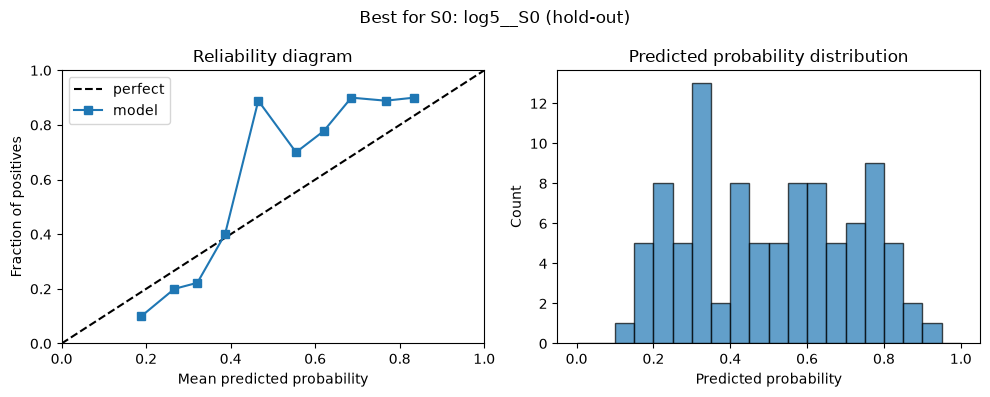

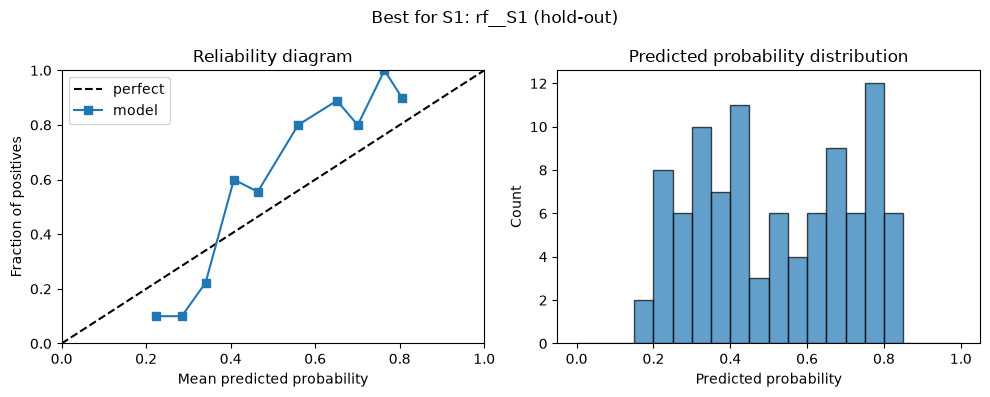

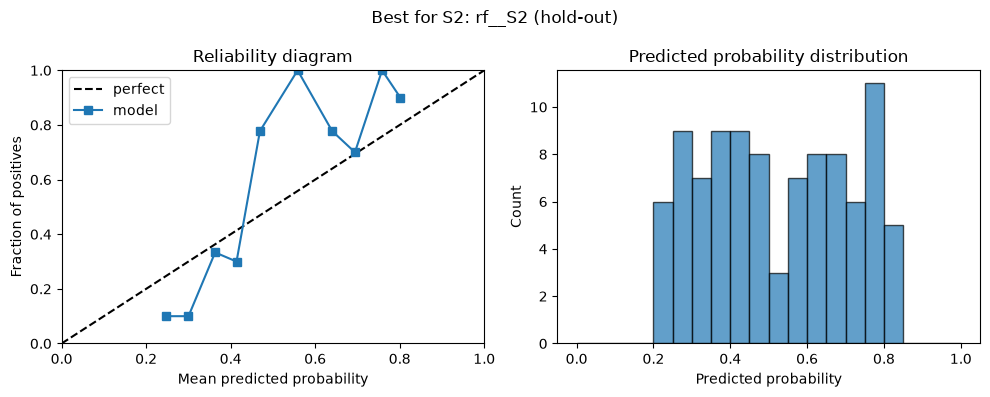

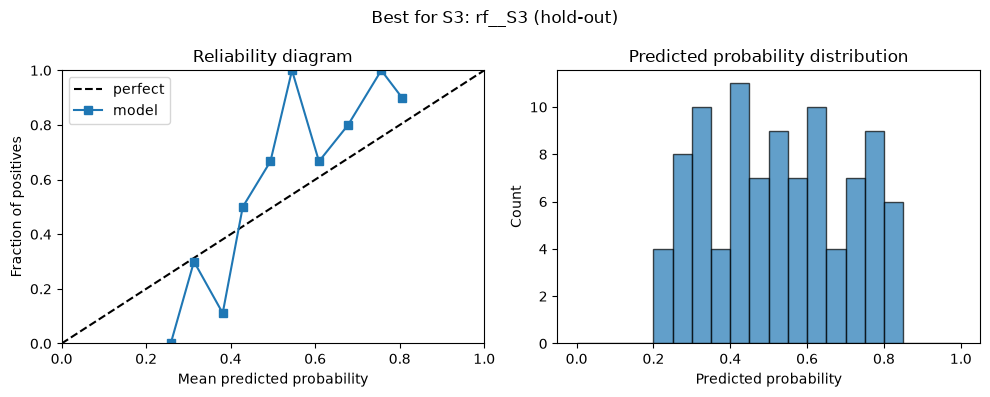

In [10]:
def plot_calibration(y_true, y_prob, title):
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy="quantile")
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].plot([0, 1], [0, 1], "k--", label="perfect")
    ax[0].plot(mean_pred, frac_pos, "s-", label="model")
    ax[0].set_xlabel("Mean predicted probability")
    ax[0].set_ylabel("Fraction of positives")
    ax[0].set_title("Reliability diagram")
    ax[0].legend(loc="upper left")
    ax[0].set_xlim(0, 1)
    ax[0].set_ylim(0, 1)
    ax[1].hist(y_prob, bins=20, range=(0, 1), edgecolor="k", alpha=0.7)
    ax[1].set_xlabel("Predicted probability")
    ax[1].set_ylabel("Count")
    ax[1].set_title("Predicted probability distribution")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

for fset in ["S0", "S1", "S2", "S3"]:
    candidates = {k: v for k, v in val_results.items() if k.endswith(f"__{fset}")}
    if not candidates:
        continue
    best_key = min(candidates, key=lambda k: candidates[k]["brier"])
    info = fitted[best_key]
    plot_calibration(
        info["y_ho"], info["proba_ho"],
        title=f"Best for {fset}: {best_key} (hold-out)"
    )

## 10. Feature importance (S3)

In [11]:
s3_features = S3

# XGBoost gain
xgb_model = fitted["xgboost__S3"]["model"]
score = xgb_model.get_booster().get_score(importance_type="gain")
xgb_imp = {f: score.get(f, 0.0) for f in s3_features}

# RF
rf_model = fitted["rf__S3"]["model"]
rf_imp = dict(zip(s3_features, rf_model.feature_importances_))

# Logistic absolute coefficients (after scaling)
logit_pipe = fitted["logistic__S3"]["model"]
coefs = np.abs(logit_pipe.named_steps["clf"].coef_.ravel())
logit_imp = dict(zip(s3_features, coefs))

rows = []
for f in s3_features:
    avg_tree = np.nanmean([xgb_imp.get(f, np.nan), rf_imp.get(f, np.nan)])
    rows.append({
        "feature": f,
        "xgb_imp": xgb_imp.get(f, np.nan),
        "rf_imp": rf_imp.get(f, np.nan),
        "logit_imp": logit_imp.get(f, np.nan),
        "avg_tree_imp": avg_tree,
    })

imp_df = pd.DataFrame(rows)
imp_df = imp_df.sort_values("avg_tree_imp", ascending=False).reset_index(drop=True)
imp_df.insert(0, "rank", imp_df.index + 1)

desc = {
    "home_win_pct_overall": "Home team overall win %",
    "away_win_pct_overall": "Away team overall win %",
    "home_win_pct_at_home": "Home team home win %",
    "away_win_pct_on_road": "Away team road win %",
    "home_points_overall": "Home team avg points scored (overall)",
    "away_points_overall": "Away team avg points scored (overall)",
    "home_points_at_home": "Home team avg points scored at home",
    "away_points_on_road": "Away team avg points scored on road",
    "home_points_allowed_overall": "Home team avg points allowed (overall)",
    "away_points_allowed_overall": "Away team avg points allowed (overall)",
    "home_points_allowed_at_home": "Home team avg points allowed at home",
    "away_points_allowed_on_road": "Away team avg points allowed on road",
    "home_rebounds_net_overall": "Home team rebound margin (overall)",
    "away_rebounds_net_overall": "Away team rebound margin (overall)",
    "home_rebounds_net_at_home": "Home team rebound margin at home",
    "away_rebounds_net_on_road": "Away team rebound margin on road",
    "home_turnovers_net_overall": "Home team turnover margin (overall)",
    "away_turnovers_net_overall": "Away team turnover margin (overall)",
    "home_turnovers_net_at_home": "Home team turnover margin at home",
    "away_turnovers_net_on_road": "Away team turnover margin on road",
    "home_fouls_net_overall": "Home team foul margin (overall)",
    "away_fouls_net_overall": "Away team foul margin (overall)",
    "home_fouls_net_at_home": "Home team foul margin at home",
    "away_fouls_net_on_road": "Away team foul margin on road",
    "rest_days_diff": "Rest days advantage (home − away)",
    "games_played_diff": "Games played difference (home − away)",
    "games_played_sum": "Total games played by both teams",
}
imp_df.insert(2, "description", imp_df["feature"].map(desc).fillna(""))

print(imp_df.to_string(index=False))
imp_df.to_csv("feature_importance_ranking.csv", index=False)
print("\nSaved → feature_importance_ranking.csv")

 rank                     feature                            description  xgb_imp   rf_imp  logit_imp  avg_tree_imp
    1        away_win_pct_overall                Away team overall win % 3.745058 0.079638   0.238421      1.912348
    2 home_points_allowed_overall Home team avg points allowed (overall) 3.511355 0.071701   0.403547      1.791528
    3 away_points_allowed_overall Away team avg points allowed (overall) 3.472793 0.064811   0.735487      1.768802
    4   away_rebounds_net_on_road       Away team rebound margin on road 3.454968 0.048235   0.421086      1.751602
    5 home_points_allowed_at_home   Home team avg points allowed at home 2.903749 0.068359   0.280589      1.486054
    6        home_win_pct_overall                Home team overall win % 2.765278 0.075287   0.127422      1.420283
    7         home_points_overall  Home team avg points scored (overall) 2.756820 0.034889   0.283193      1.395855
    8      away_fouls_net_on_road          Away team foul margin on road

## 11. Calibration diagnostics

Expected Calibration Error (ECE), Maximum Calibration Error (MCE), and calibration slope / intercept for the four finalists.

In [12]:
from sklearn.linear_model import LogisticRegression as LR_cal

FINALISTS = {
    "log5__S0":     "Log5–S0",
    "logistic__S0": "Logistic–S0",
    "rf__S1":       "RF–S1",
    "xgboost__S3":  "XGB–S3",
}

def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    mce = 0.0
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1] if i < n_bins-1 else y_prob <= bins[i+1])
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()
        gap = abs(acc - conf)
        ece += mask.mean() * gap
        mce = max(mce, gap)
    return ece, mce

def calibration_slope_intercept(y_true, y_prob):
    """Fit logit(y) ~ logit(p). Slope≈1 and intercept≈0 indicate good calibration."""
    p = np.clip(y_prob, 1e-6, 1-1e-6)
    logit_p = np.log(p / (1 - p)).reshape(-1, 1)
    lr = LR_cal(penalty=None, solver="lbfgs", max_iter=1000)
    lr.fit(logit_p, y_true)
    return float(lr.coef_[0, 0]), float(lr.intercept_[0])

cal_rows = []
for key, label in FINALISTS.items():
    info = fitted[key]
    y, p = info["y_ho"], info["proba_ho"]
    ece, mce = expected_calibration_error(y, p)
    slope, intercept = calibration_slope_intercept(y, p)
    cal_rows.append({
        "finalist": label,
        "ECE": ece,
        "MCE": mce,
        "cal_slope": slope,
        "cal_intercept": intercept,
        "brier": results[key]["brier"],
        "logloss": results[key]["logloss"],
    })

cal_df = pd.DataFrame(cal_rows).set_index("finalist")
print(cal_df.round(4).to_string())
print("\nIdeal: ECE/MCE → 0, slope → 1, intercept → 0")


                ECE     MCE  cal_slope  cal_intercept   brier  logloss
finalist                                                              
Log5–S0      0.1528  0.3241     1.7748         0.5503  0.1697   0.5175
Logistic–S0  0.2198  0.2939     3.6827        -0.0684  0.1890   0.5668
RF–S1        0.1521  0.3524     1.9712         0.4646  0.1661   0.5126
XGB–S3       0.1301  0.3526     1.0333         0.8132  0.1796   0.5363

Ideal: ECE/MCE → 0, slope → 1, intercept → 0


## 12. Calibration curves

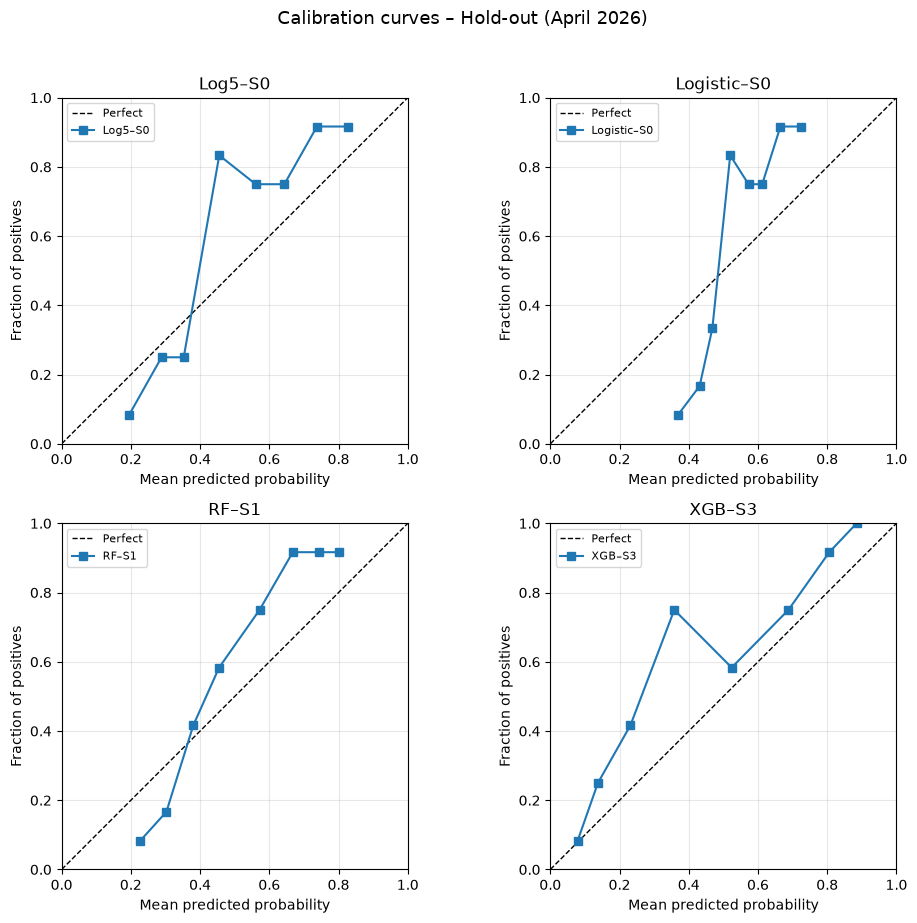

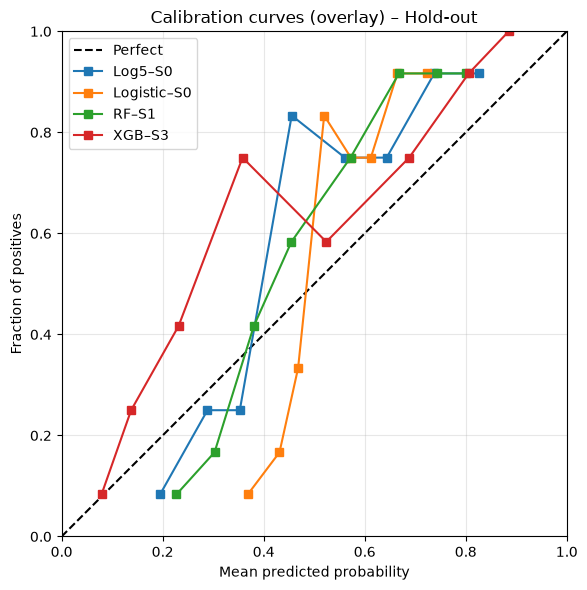

In [13]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.ravel()

for ax, (key, label) in zip(axes, FINALISTS.items()):
    y = fitted[key]["y_ho"]
    p = fitted[key]["proba_ho"]
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=8, strategy="quantile")

    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect")
    ax.plot(mean_pred, frac_pos, "s-", color="C0", label=label)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_title(label)
    ax.legend(loc="upper left", fontsize=8)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

fig.suptitle("Calibration curves – Hold-out (April 2026)", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

# Overlay version
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Perfect")
colors = ["C0", "C1", "C2", "C3"]
for (key, label), c in zip(FINALISTS.items(), colors):
    y = fitted[key]["y_ho"]
    p = fitted[key]["proba_ho"]
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=8, strategy="quantile")
    ax.plot(mean_pred, frac_pos, "s-", color=c, label=label)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration curves (overlay) – Hold-out")
ax.legend(loc="upper left")
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## 13. Bootstrap confidence intervals

In [14]:
def bootstrap_ci(y, p, metric_fn, n_boot=1000, alpha=0.05, rng=None):
    rng = np.random.default_rng(RANDOM_STATE if rng is None else rng)
    y = np.asarray(y)
    p = np.asarray(p)
    n = len(y)
    stats = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        stats.append(metric_fn(y[idx], p[idx]))
    stats = np.asarray(stats)
    lo = np.percentile(stats, 100 * alpha / 2)
    hi = np.percentile(stats, 100 * (1 - alpha / 2))
    return float(np.mean(stats)), float(lo), float(hi)

def brier(y, p):
    return brier_score_loss(y, np.clip(p, 1e-6, 1-1e-6))

def logloss_fn(y, p):
    return log_loss(y, np.clip(p, 1e-6, 1-1e-6))

boot_rows = []
for key, label in FINALISTS.items():
    info = fitted[key]
    y, p = info["y_ho"], info["proba_ho"]
    b_mean, b_lo, b_hi = bootstrap_ci(y, p, brier)
    l_mean, l_lo, l_hi = bootstrap_ci(y, p, logloss_fn)
    boot_rows.append({
        "finalist": label,
        "brier": b_mean,
        "brier_lo": b_lo,
        "brier_hi": b_hi,
        "logloss": l_mean,
        "logloss_lo": l_lo,
        "logloss_hi": l_hi,
    })

boot_df = pd.DataFrame(boot_rows).set_index("finalist")
print(boot_df.round(4).to_string())


              brier  brier_lo  brier_hi  logloss  logloss_lo  logloss_hi
finalist                                                                
Log5–S0      0.1702    0.1417    0.1992   0.5185      0.4558      0.5837
Logistic–S0  0.1893    0.1723    0.2065   0.5676      0.5323      0.6039
RF–S1        0.1665    0.1396    0.1921   0.5133      0.4551      0.5697
XGB–S3       0.1797    0.1407    0.2233   0.5370      0.4369      0.6483


## 14. Pairwise significance tests

In [15]:
from itertools import combinations

def paired_bootstrap_diff(y, p1, p2, metric_fn, n_boot=1000, alpha=0.05):
    rng = np.random.default_rng(RANDOM_STATE)
    y, p1, p2 = map(np.asarray, (y, p1, p2))
    n = len(y)
    diffs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        diffs.append(metric_fn(y[idx], p1[idx]) - metric_fn(y[idx], p2[idx]))
    diffs = np.asarray(diffs)
    lo = np.percentile(diffs, 100 * alpha / 2)
    hi = np.percentile(diffs, 100 * (1 - alpha / 2))
    return float(np.mean(diffs)), float(lo), float(hi), (lo > 0 or hi < 0)

pairs = list(combinations(FINALISTS.keys(), 2))
pair_rows = []
y_ref = fitted["rf__S1"]["y_ho"]

for k1, k2 in pairs:
    p1 = fitted[k1]["proba_ho"]
    p2 = fitted[k2]["proba_ho"]
    lab1, lab2 = FINALISTS[k1], FINALISTS[k2]
    for metric_name, fn in [("brier", brier), ("logloss", logloss_fn)]:
        mean_d, lo, hi, sig = paired_bootstrap_diff(y_ref, p1, p2, fn)
        pair_rows.append({
            "pair": f"{lab1} vs {lab2}",
            "metric": metric_name,
            "diff": mean_d,
            "ci_lo": lo,
            "ci_hi": hi,
            "significant": sig,
        })

pair_df = pd.DataFrame(pair_rows)
print(pair_df.round(4).to_string(index=False))
print("\nInterpretation: diff = metric(A) − metric(B). Positive means A is worse.")
print("significant=True when the 95 % CI excludes zero.")


                  pair  metric    diff   ci_lo   ci_hi  significant
Log5–S0 vs Logistic–S0   brier -0.0191 -0.0343 -0.0025         True
Log5–S0 vs Logistic–S0 logloss -0.0491 -0.0842 -0.0137         True
      Log5–S0 vs RF–S1   brier  0.0037 -0.0093  0.0171        False
      Log5–S0 vs RF–S1 logloss  0.0052 -0.0232  0.0346        False
     Log5–S0 vs XGB–S3   brier -0.0095 -0.0402  0.0177        False
     Log5–S0 vs XGB–S3 logloss -0.0184 -0.0989  0.0507        False
  Logistic–S0 vs RF–S1   brier  0.0229  0.0072  0.0381         True
  Logistic–S0 vs RF–S1 logloss  0.0543  0.0200  0.0874         True
 Logistic–S0 vs XGB–S3   brier  0.0097 -0.0254  0.0425        False
 Logistic–S0 vs XGB–S3 logloss  0.0306 -0.0609  0.1156        False
       RF–S1 vs XGB–S3   brier -0.0132 -0.0414  0.0132        False
       RF–S1 vs XGB–S3 logloss -0.0237 -0.1017  0.0433        False

Interpretation: diff = metric(A) − metric(B). Positive means A is worse.
significant=True when the 95 % CI excludes

## 15. Platt recalibration

Logistic (Platt) scaling is fit on validation predictions and applied to the hold-out set for RF–S1 and XGB–S3.

In [16]:
def platt_scale(p_val, y_val, p_ho):
    p_val = np.clip(p_val, 1e-6, 1-1e-6)
    logit_val = np.log(p_val / (1 - p_val)).reshape(-1, 1)
    lr = LR_cal(penalty=None, solver="lbfgs", max_iter=1000)
    lr.fit(logit_val, y_val)
    p_ho = np.clip(p_ho, 1e-6, 1-1e-6)
    logit_ho = np.log(p_ho / (1 - p_ho)).reshape(-1, 1)
    return lr.predict_proba(logit_ho)[:, 1], lr

platt_rows = []
for key in ["rf__S1", "xgboost__S3"]:
    label = FINALISTS[key]
    feats = FEATURE_SETS[key.split("__")[1]]
    X_va, y_va = get_xy(val, feats)
    X_ho, y_ho = get_xy(hold, feats)
    model = fitted[key]["model"]
    p_va = model.predict_proba(X_va)[:, 1]
    p_ho_raw = fitted[key]["proba_ho"]
    p_ho_cal, lr = platt_scale(p_va, y_va, p_ho_raw)

    ece_raw, mce_raw = expected_calibration_error(y_ho, p_ho_raw)
    ece_cal, mce_cal = expected_calibration_error(y_ho, p_ho_cal)
    slope_raw, _ = calibration_slope_intercept(y_ho, p_ho_raw)
    slope_cal, _ = calibration_slope_intercept(y_ho, p_ho_cal)

    platt_rows.append({
        "model": label,
        "brier_raw": brier(y_ho, p_ho_raw),
        "brier_platt": brier(y_ho, p_ho_cal),
        "logloss_raw": logloss_fn(y_ho, p_ho_raw),
        "logloss_platt": logloss_fn(y_ho, p_ho_cal),
        "ECE_raw": ece_raw,
        "ECE_platt": ece_cal,
        "slope_raw": slope_raw,
        "slope_platt": slope_cal,
    })

platt_df = pd.DataFrame(platt_rows).set_index("model")
print(platt_df.round(4).to_string())
print("\nPlatt scaling is fit on validation only → no hold-out leakage.")


        brier_raw  brier_platt  logloss_raw  logloss_platt  ECE_raw  ECE_platt  slope_raw  slope_platt
model                                                                                                 
RF–S1      0.1661       0.1475       0.5126         0.4623   0.1521     0.0907     1.9712       1.2262
XGB–S3     0.1796       0.1638       0.5363         0.5006   0.1301     0.1138     1.0333       1.4928

Platt scaling is fit on validation only → no hold-out leakage.


## 16. Summary

Four finalists were selected by assigning each model its best feature regime:

| Finalist        | Regime | Role                            |
|-----------------|--------|---------------------------------|
| Log5            | S0     | Closed-form baseline            |
| Logistic        | S0     | Best linear model               |
| Random Forest   | S1     | Best overall probability model  |
| XGBoost         | S3     | Best boosted model              |

**Random Forest on S1** achieves the lowest Brier score and log-loss on the April hold-out.  
The two-feature Log5 baseline remains close behind, illustrating that a simple, well-calibrated model can stay competitive when only pre-game information is available.

Diagnostics included above: ECE/MCE, calibration slopes, bootstrap confidence intervals, pairwise significance tests, and Platt recalibration.